In [1]:
import os, sys, json, random, time
from pathlib import Path
from dataclasses import dataclass

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T


In [2]:
# ---------------------------
# PATHS
# ---------------------------
TRAIN_JSON = Path("/zpool/vladlab/data_drive/stimulus_sets/geogaze_COCO_stim/coco_working/working_v3/instances_train_filtered3.json")
TRAIN_IMG_DIR = Path("/zpool/vladlab/data_drive/stimulus_sets/geogaze_COCO_stim/coco_working/working_v3/train_working3")  # folder containing the training images referenced by TRAIN_JSON

# Your local CORnet repo clone
CORN_NET_REPO = Path("/zpool/vladlab/active_drive/omaltz/git_repos/CORnet")  # e.g., /zpool/vladlab/active_drive/omaltz/git_repos/CORnet

# Output directory where runs are saved
OUT_ROOT = Path("cornet_z_individuation_big_123")

# ---------------------------
# Training settings
# ---------------------------
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 8
EPOCHS = 50
LR = 1e-3
WEIGHT_DECAY = 1e-4

VAL_FRACTION = 0.1  # random chunk of TRAIN used for validation

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


DEVICE: cuda


In [4]:
with open(TRAIN_JSON, "r") as f:
    coco = json.load(f)

images = coco["images"]
annotations = coco["annotations"]

print("Images:", len(images))
print("Annotations:", len(annotations))

# Count annotations per image_id
from collections import defaultdict
ann_count = defaultdict(int)
for ann in annotations:
    ann_count[ann["image_id"]] += 1

# Build (image_id, file_name, count) records
records = []
missing_files = []
bad_counts = []

for im in images:
    img_id = im["id"]
    fname = im["file_name"]
    p = TRAIN_IMG_DIR / fname
    if not p.exists():
        missing_files.append(fname)
        continue

    c = ann_count.get(img_id, 0)
    # You said there are no 0-object images and max is 5 after filtering
    if c < 1 or c > 5:
        bad_counts.append((fname, c))
        continue

    records.append((img_id, fname, c))

print("Records kept:", len(records))
print("Missing files:", len(missing_files), (missing_files[:5] if missing_files else ""))
print("Bad counts:", len(bad_counts), (bad_counts[:5] if bad_counts else ""))

assert len(missing_files) == 0, "Fix missing image files or remove them from JSON."
assert len(bad_counts) == 0, "Your JSON contains images with 0 or >5 annotations—check filtering."

print(records)

Images: 33953
Annotations: 60549
Records kept: 33953
Missing files: 0 
Bad counts: 0 
[(118113, '000000118113.jpg', 1), (86408, '000000086408.jpg', 2), (386164, '000000386164.jpg', 3), (269105, '000000269105.jpg', 2), (173350, '000000173350.jpg', 3), (360772, '000000360772.jpg', 1), (191381, '000000191381.jpg', 1), (258985, '000000258985.jpg', 1), (509822, '000000509822.jpg', 1), (580041, '000000580041.jpg', 2), (556616, '000000556616.jpg', 3), (256668, '000000256668.jpg', 1), (383445, '000000383445.jpg', 2), (565797, '000000565797.jpg', 2), (50125, '000000050125.jpg', 1), (364521, '000000364521.jpg', 1), (241876, '000000241876.jpg', 2), (310103, '000000310103.jpg', 1), (32992, '000000032992.jpg', 1), (540763, '000000540763.jpg', 1), (32907, '000000032907.jpg', 1), (75051, '000000075051.jpg', 1), (549399, '000000549399.jpg', 1), (79472, '000000079472.jpg', 2), (437218, '000000437218.jpg', 1), (432176, '000000432176.jpg', 2), (281533, '000000281533.jpg', 4), (77123, '000000077123.jpg', 

In [5]:
from collections import Counter

# records is a list of (image_id, filename, count)
counts = [c for (_, _, c) in records]

count_dist = Counter(counts)
total = len(counts)

print("Object count distribution:")
for k in range(1, 6):
    n = count_dist.get(k, 0)
    pct = 100.0 * n / total if total > 0 else 0.0
    print(f"  {k} object: {n:6d} images ({pct:5.1f}%)")

print("-" * 40)
print(f"Total images used: {total}")


Object count distribution:
  1 object:  17140 images ( 50.5%)
  2 object:  10074 images ( 29.7%)
  3 object:   4351 images ( 12.8%)
  4 object:   1732 images (  5.1%)
  5 object:    656 images (  1.9%)
----------------------------------------
Total images used: 33953


In [6]:
random.shuffle(records)
n_total = len(records)
n_val = int(round(n_total * VAL_FRACTION))

val_records = records[:n_val]
train_records = records[n_val:]

print("Train:", len(train_records))
print("Val:", len(val_records))


Train: 30558
Val: 3395


In [7]:
train_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

val_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

class COCODetectCountDataset(Dataset):
    """
    Each item:
      x: image tensor
      y: class index in {0..4} corresponding to count {1..5}
    """
    def __init__(self, records, img_dir: Path, tfms):
        self.records = records
        self.img_dir = img_dir
        self.tfms = tfms

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        _, fname, count = self.records[idx]
        path = self.img_dir / fname
        img = Image.open(path).convert("RGB")
        x = self.tfms(img)
        y = count - 1  # map {1..5} -> {0..4}
        return x, torch.tensor(y, dtype=torch.long)

train_ds = COCODetectCountDataset(train_records, TRAIN_IMG_DIR, train_tfms)
val_ds   = COCODetectCountDataset(val_records,   TRAIN_IMG_DIR, val_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)


In [8]:
sys.path.insert(0, str(CORN_NET_REPO))
import cornet
print("Imported cornet from:", cornet.__file__)



Imported cornet from: /zpool/vladlab/active_drive/omaltz/git_repos/CORnet/cornet/__init__.py


In [9]:
def replace_last_linear(model: nn.Module, out_features: int):
    last_name, last_linear = None, None
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            last_name, last_linear = name, module
    if last_linear is None:
        raise RuntimeError("No nn.Linear found in model.")

    parent = model
    parts = last_name.split(".")
    for p in parts[:-1]:
        parent = getattr(parent, p)

    setattr(parent, parts[-1], nn.Linear(last_linear.in_features, out_features))
    return model, last_linear.in_features, last_name

model = cornet


In [10]:
# Build CORnet-Z from scratch (no pretrained weights)
model = cornet.cornet_z(pretrained=False)

# Replace the final linear layer to output 5 classes (counts 1..5)
model, in_features, last_name = replace_last_linear(model, out_features=5)
print(f"Replaced {last_name} with Linear({in_features} -> 5)")

model = model.to(DEVICE)
print("Model on:", DEVICE)


Replaced module.decoder.linear with Linear(512 -> 5)
Model on: cuda


In [11]:
from collections import Counter

train_counts = [c for (_, _, c) in train_records]  # counts in {1..5}
dist = Counter(train_counts)
print("Train count distribution:", dist)

# Compute inverse-frequency weights for classes 0..4 (counts 1..5)
# weight[class_idx] corresponds to count = class_idx+1
weights = []
for cls in range(5):
    count_value = cls + 1
    freq = dist.get(count_value, 0)
    weights.append(1.0 / max(freq, 1))

weights = torch.tensor(weights, dtype=torch.float32)
weights = weights / weights.mean()  # normalize so average weight ~ 1
print("Class weights (for counts 1..5):", weights.tolist())


Train count distribution: Counter({1: 15421, 2: 9080, 3: 3913, 4: 1557, 5: 587})
Class weights (for counts 1..5): [0.11678291112184525, 0.19833803176879883, 0.4602375030517578, 1.1566534042358398, 3.067988395690918]


In [12]:
# If you ran Cell 6 and want to use weights:
USE_CLASS_WEIGHTS = False

class_weights = weights.to(DEVICE) if USE_CLASS_WEIGHTS else None

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Simple cosine schedule across epochs
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


In [13]:
import numpy as np

def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    # logits: (B,5), y: (B,)
    pred = logits.argmax(dim=1)
    return (pred == y).float().mean().item()

def confusion_matrix_5(y_true: np.ndarray, y_pred: np.ndarray, num_classes=5) -> np.ndarray:
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1
    return cm

def balanced_accuracy_from_cm(cm: np.ndarray) -> float:
    # mean recall across classes (ignore classes with 0 support)
    recalls = []
    for i in range(cm.shape[0]):
        denom = cm[i].sum()
        if denom > 0:
            recalls.append(cm[i, i] / denom)
    return float(np.mean(recalls)) if recalls else 0.0

def pretty_print_cm(cm: np.ndarray):
    # rows = true class, cols = predicted class
    header = "pred→   " + "  ".join([f"{i+1:>3d}" for i in range(5)])
    print(header)
    for i in range(5):
        row = "true " + f"{i+1:>1d}" + "  " + "  ".join([f"{cm[i,j]:>3d}" for j in range(5)])
        print(row)


In [14]:
from tqdm.auto import tqdm

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    n_batches = 0

    for x, y in tqdm(loader, desc="train", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_acc += accuracy_from_logits(logits.detach(), y)
        n_batches += 1

    return running_loss / max(n_batches, 1), running_acc / max(n_batches, 1)


@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_acc = 0.0
    n_batches = 0

    all_true = []
    all_pred = []

    for x, y in tqdm(loader, desc="val", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        pred = logits.argmax(dim=1)

        running_loss += loss.item()
        running_acc += (pred == y).float().mean().item()
        n_batches += 1

        all_true.append(y.cpu().numpy())
        all_pred.append(pred.cpu().numpy())

    y_true = np.concatenate(all_true) if all_true else np.array([])
    y_pred = np.concatenate(all_pred) if all_pred else np.array([])

    cm = confusion_matrix_5(y_true, y_pred, num_classes=5) if y_true.size else np.zeros((5,5), dtype=np.int64)
    bal_acc = balanced_accuracy_from_cm(cm)

    return running_loss / max(n_batches, 1), running_acc / max(n_batches, 1), bal_acc, cm


/home/tuv00299@tu.temple.edu/.conda/envs/geogaze_model/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
from datetime import datetime

run_dir = OUT_ROOT / datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir.mkdir(parents=True, exist_ok=True)
print("Run dir:", run_dir)

def save_ckpt(path: Path, model, optimizer, scheduler, epoch, best_metric, config: dict):
    ckpt = {
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict() if scheduler is not None else None,
        "epoch": epoch,
        "best_metric": best_metric,
        "config": config,
    }
    torch.save(ckpt, path)

config = dict(
    TRAIN_JSON=str(TRAIN_JSON),
    TRAIN_IMG_DIR=str(TRAIN_IMG_DIR),
    IMG_SIZE=IMG_SIZE,
    BATCH_SIZE=BATCH_SIZE,
    EPOCHS=EPOCHS,
    LR=LR,
    WEIGHT_DECAY=WEIGHT_DECAY,
    VAL_FRACTION=VAL_FRACTION,
    SEED=SEED,
    USE_CLASS_WEIGHTS=USE_CLASS_WEIGHTS,
)


Run dir: cornet_z_individuation_big_123/20260120_132552


In [16]:
x, y = next(iter(train_loader))
print("x:", x.shape, x.dtype)   # (B,3,H,W)
print("y:", y.shape, y.dtype)   # (B,) long in [0..4]
print("y unique:", torch.unique(y))

x = x.to(DEVICE)
y = y.to(DEVICE)

model.train()
optimizer.zero_grad(set_to_none=True)
logits = model(x)
print("logits:", logits.shape)  # (B,5)

loss = criterion(logits, y)
print("loss:", float(loss))

loss.backward()
grads = [p.grad for p in model.parameters() if p.grad is not None]
print("params with grads:", len(grads))
print("first grad norm:", grads[0].norm().item() if grads else "NO GRADS")


x: torch.Size([64, 3, 224, 224]) torch.float32
y: torch.Size([64]) torch.int64
y unique: tensor([0, 1, 2, 3])
logits: torch.Size([64, 5])
loss: 1.5978070497512817
params with grads: 10
first grad norm: 0.25146737694740295


In [ ]:
best_bal_acc = -1.0
best_path = run_dir / "best.pt"
last_path = run_dir / "last.pt"

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_acc, val_bal_acc, cm = eval_one_epoch(model, val_loader, criterion, DEVICE)

    if scheduler is not None:
        scheduler.step()

    lr_now = optimizer.param_groups[0]["lr"]

    print(f"\nEpoch {epoch}/{EPOCHS}  lr={lr_now:.6f}")
    print(f"Train: loss={train_loss:.4f}  acc={train_acc:.3f}")
    print(f"Val:   loss={val_loss:.4f}  acc={val_acc:.3f}  bal_acc={val_bal_acc:.3f}")
    print("Confusion matrix (rows=true count, cols=pred count):")
    pretty_print_cm(cm)

    # Save last every epoch
    save_ckpt(last_path, model, optimizer, scheduler, epoch, best_bal_acc, config)

    # Save best
    if val_bal_acc > best_bal_acc:
        best_bal_acc = val_bal_acc
        save_ckpt(best_path, model, optimizer, scheduler, epoch, best_bal_acc, config)
        print(f" Saved best checkpoint: {best_path}")


train:  79%|███████▉  | 377/477 [02:07<00:32,  3.06it/s]

In [18]:
# Cell 1 — Imports + config (EDIT the 4 paths)
import sys, json, random
from pathlib import Path
from collections import defaultdict

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.transforms as T

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# -------- EDIT THESE --------
CORN_NET_REPO = Path("/zpool/vladlab/active_drive/omaltz/git_repos/CORnet")          # your cloned CORnet repo
CKPT_PATH     = Path("/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_scripts/models/cornet_z_individuation_big_200/best.pt")         # your trained individuation checkpoint
TEST_IMG_DIR  = Path("/zpool/vladlab/data_drive/stimulus_sets/geogaze_COCO_stim/coco_working/working_v3/train_working3")     # folder with many images (we will sample 10)
TEST_JSON     = Path("/zpool/vladlab/data_drive/stimulus_sets/geogaze_COCO_stim/coco_working/working_v3/instances_train_filtered3.json")  # COCO-format json matching these images

N_SAMPLES = 3
SEED = 85478
IMG_SIZE = 224
threshold_note = "Individuation uses argmax over 5-way softmax (no threshold)."

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


DEVICE: cuda


In [19]:
# Cell 2 — Load COCO JSON and build filename->(image_id, gt_count) lookup
with open(TEST_JSON, "r") as f:
    coco = json.load(f)

images = coco["images"]
annotations = coco["annotations"]

file_to_id = {}
for im in images:
    file_to_id[im["file_name"]] = im["id"]

ann_count = defaultdict(int)
for ann in annotations:
    ann_count[ann["image_id"]] += 1

file_to_gtcount = {}
bad_counts = []
for fname, img_id in file_to_id.items():
    c = ann_count.get(img_id, 0)
    file_to_gtcount[fname] = c
    if c < 1 or c > 5:
        bad_counts.append((fname, c))

print("Images in JSON:", len(images))
print("Annotations in JSON:", len(annotations))
print("Example filename->gtcount:", list(file_to_gtcount.items())[:3])

if bad_counts:
    print("\nWARNING: Some images have gt counts outside 1..5 (first 10 shown):")
    print(bad_counts[:10])
    print("These will still be displayed, but your model was trained for counts 1..5.")


Images in JSON: 33953
Annotations in JSON: 60549
Example filename->gtcount: [('000000118113.jpg', 1), ('000000086408.jpg', 2), ('000000386164.jpg', 3)]


In [20]:
# Cell 3 — Add CORnet to sys.path and rebuild model architecture
sys.path.insert(0, str(CORN_NET_REPO))
import cornet
print("Imported cornet from:", cornet.__file__)

def replace_last_linear(model: nn.Module, out_features: int):
    last_name, last_linear = None, None
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            last_name, last_linear = name, module
    if last_linear is None:
        raise RuntimeError("No nn.Linear found in model.")

    parent = model
    parts = last_name.split(".")
    for p in parts[:-1]:
        parent = getattr(parent, p)

    setattr(parent, parts[-1], nn.Linear(last_linear.in_features, out_features))
    return model, last_name, last_linear.in_features

model = cornet.cornet_z(pretrained=False)
model, last_name, in_feats = replace_last_linear(model, out_features=5)
print(f"Replaced final layer {last_name} with Linear({in_feats} -> 5)")
model = model.to(DEVICE)


Imported cornet from: /zpool/vladlab/active_drive/omaltz/git_repos/CORnet/cornet/__init__.py
Replaced final layer module.decoder.linear with Linear(512 -> 5)


In [21]:
# Cell 4 — Load checkpoint weights into the rebuilt model
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)

# Support both {"model_state": ...} and raw state_dict checkpoints
state = ckpt["model_state"] if isinstance(ckpt, dict) and "model_state" in ckpt else ckpt

missing, unexpected = model.load_state_dict(state, strict=False)
print("Loaded weights from:", CKPT_PATH)
print("Missing keys:", len(missing))
print("Unexpected keys:", len(unexpected))

model.eval()


Loaded weights from: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_scripts/models/cornet_z_individuation_big_200/best.pt
Missing keys: 0
Unexpected keys: 0


DataParallel(
  (module): Sequential(
    (V1): CORblock_Z(
      (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
      (nonlin): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (output): Identity()
    )
    (V2): CORblock_Z(
      (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (nonlin): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (output): Identity()
    )
    (V4): CORblock_Z(
      (conv): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (nonlin): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (output): Identity()
    )
    (IT): CORblock_Z(
      (conv): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (nonlin): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=3, strid

In [22]:
# Cell 5 — Preprocessing + single-image prediction (count 1..5)
eval_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

@torch.no_grad()
def predict_count_from_path(image_path: str | Path):
    image_path = Path(image_path)
    img = Image.open(image_path).convert("RGB")
    x = eval_tfms(img).unsqueeze(0).to(DEVICE)  # (1,3,H,W)

    logits = model(x)[0]              # (5,)
    probs = torch.softmax(logits, 0)  # (5,)
    pred_cls = int(torch.argmax(probs).item())   # 0..4
    pred_count = pred_cls + 1                     # 1..5

    return img, pred_count, probs.detach().cpu().numpy()


In [23]:
# Cell 6 — Sample 10 random images from folder and match to JSON ground truth
exts = (".jpg", ".jpeg", ".png")

all_paths = []
for ext in exts:
    all_paths += list(TEST_IMG_DIR.glob(f"*{ext}"))

if len(all_paths) < N_SAMPLES:
    raise ValueError(f"Found only {len(all_paths)} images in {TEST_IMG_DIR}, need at least {N_SAMPLES}")

chosen = random.sample(all_paths, N_SAMPLES)

paired = []
not_in_json = []
missing_on_disk = []

for p in chosen:
    fname = p.name
    gt = file_to_gtcount.get(fname, None)
    if gt is None:
        not_in_json.append(fname)
        continue
    if not p.exists():
        missing_on_disk.append(str(p))
        continue
    paired.append((p, gt))

print(f"Chosen: {len(chosen)}")
print(f"Paired with JSON GT: {len(paired)}")
if not_in_json:
    print("WARNING: These sampled files were not found in JSON (first 10):", not_in_json[:10])
if missing_on_disk:
    print("WARNING: These sampled files were missing on disk (first 10):", missing_on_disk[:10])

# If too many were skipped, sample again from only JSON-matching filenames
if len(paired) < N_SAMPLES:
    # Build list of files that exist on disk AND in JSON
    candidates = [p for p in all_paths if p.name in file_to_gtcount]
    if len(candidates) < N_SAMPLES:
        raise RuntimeError("Not enough images that appear in both the folder and the JSON.")
    paired = [(p, file_to_gtcount[p.name]) for p in random.sample(candidates, N_SAMPLES)]
    print("Resampled from JSON-matching files. Paired:", len(paired))


Chosen: 3
Paired with JSON GT: 3


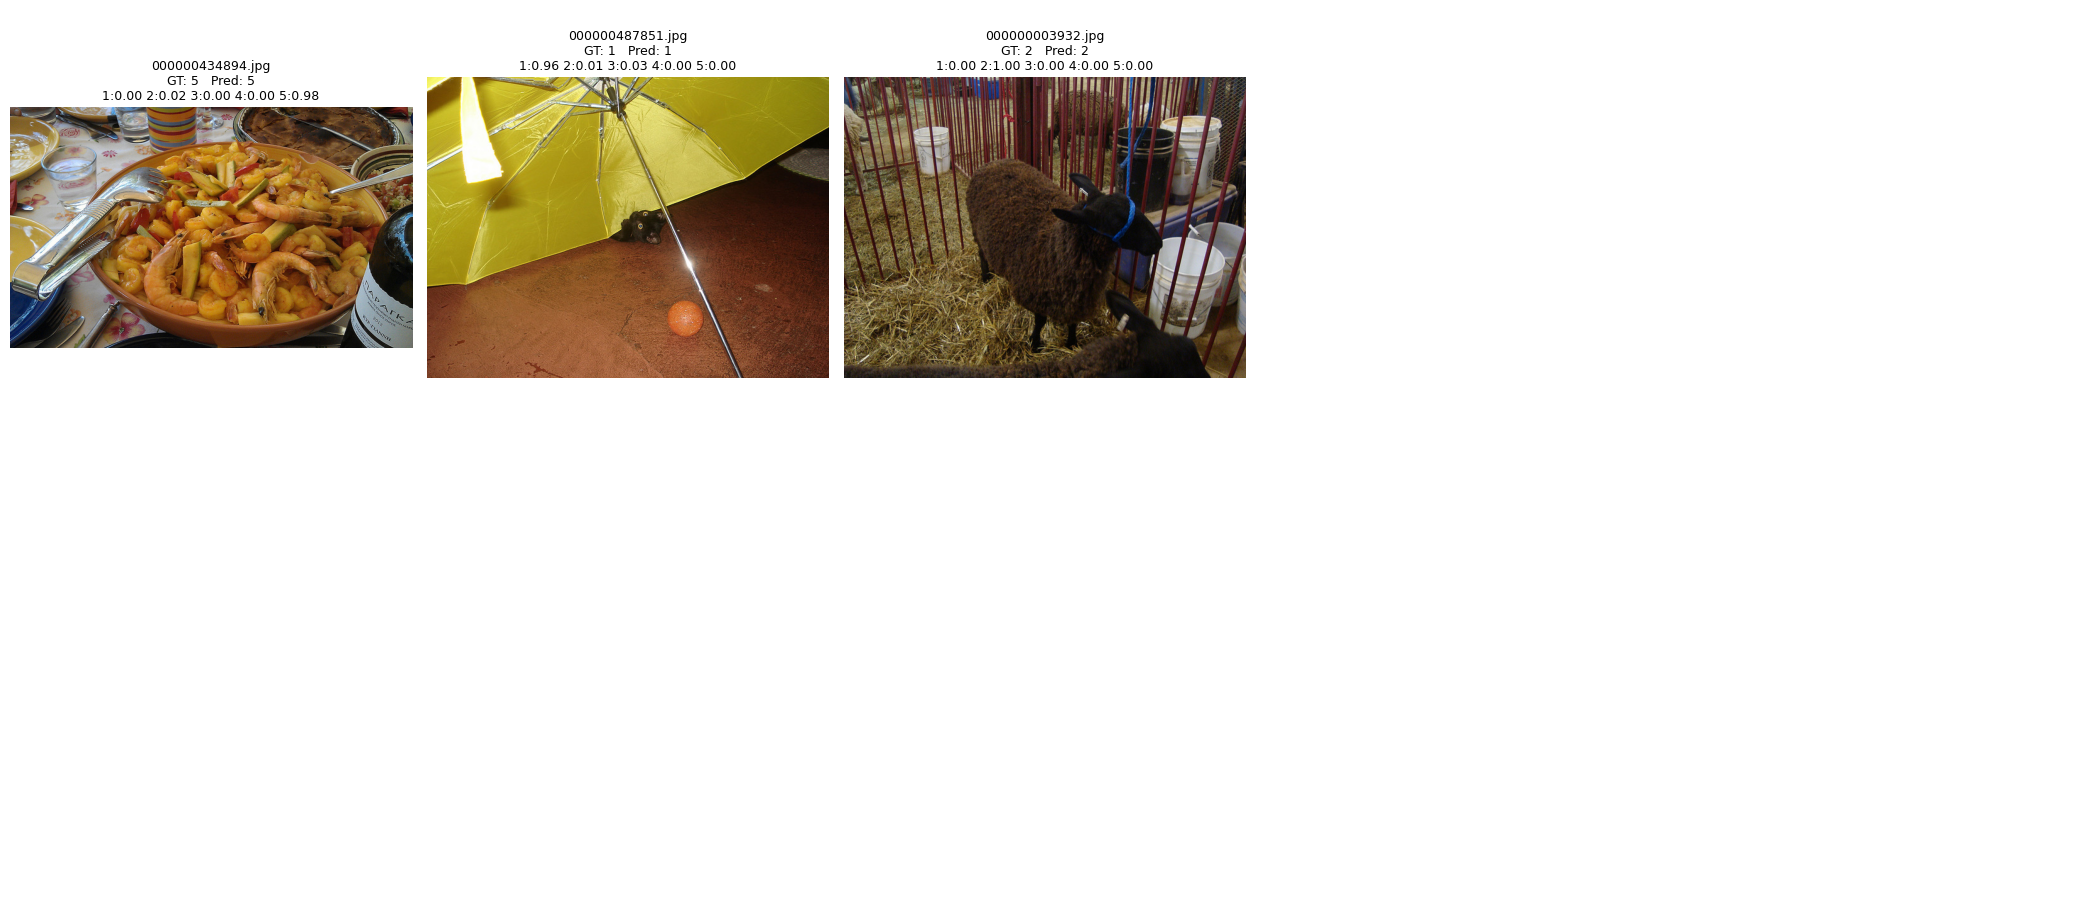

Accuracy on these 3 samples: 3/3 = 1.000
Individuation uses argmax over 5-way softmax (no threshold).


In [24]:
# Cell 7 — Run predictions and show a grid with GT vs Pred + probabilities
rows, cols = 2, 5  # 10 images total
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.2, rows * 4.6))
axes = axes.flatten()

correct = 0
for ax, (img_path, gt_count) in zip(axes, paired):
    img, pred_count, probs = predict_count_from_path(img_path)
    correct += int(pred_count == gt_count)

    ax.imshow(img)
    ax.axis("off")

    # probs correspond to counts 1..5
    prob_str = " ".join([f"{i+1}:{probs[i]:.2f}" for i in range(5)])
    title = (
        f"{img_path.name}\n"
        f"GT: {gt_count}   Pred: {pred_count}\n"
        f"{prob_str}"
    )
    ax.set_title(title, fontsize=9)

# If grid has extra axes (shouldn't here), hide them
for ax in axes[len(paired):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

print(f"Accuracy on these {len(paired)} samples: {correct}/{len(paired)} = {correct/len(paired):.3f}")
print(threshold_note)


In [ ]:
# Cell 7 — Run predictions and show a grid with GT vs Pred + probabilities
rows, cols = 2, 5  # 10 images total
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.2, rows * 4.6))
axes = axes.flatten()

correct = 0
for ax, (img_path, gt_count) in zip(axes, paired):
    img, pred_count, probs = predict_count_from_path(img_path)
    correct += int(pred_count == gt_count)

    ax.imshow(img)
    ax.axis("off")

    # probs correspond to counts 1..5
    prob_str = " ".join([f"{i+1}:{probs[i]:.2f}" for i in range(5)])
    title = (
        f"{img_path.name}\n"
        f"GT: {gt_count}   Pred: {pred_count}\n"
        f"{prob_str}"
    )
    ax.set_title(title, fontsize=9)

# If grid has extra axes (shouldn't here), hide them
for ax in axes[len(paired):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

print(f"Accuracy on these {len(paired)} samples: {correct}/{len(paired)} = {correct/len(paired):.3f}")
